# Customer Segmentation using K-Means Clustering

## Machine Learning Project

This project uses the K-Means clustering algorithm to group mall customers based on their Annual Income and Spending Score.

 **## 1. Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

**## 2. Load the Dataset**

In [2]:
import pandas as pd

df = pd.read_csv('/content/Mall_Customers.csv')

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


**## 3. Explore the Dataset**

In [3]:
# Dataset size
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Dataset information
print("\nDataset Info:")
df.info()

Dataset Shape: (200, 5)

Columns:
Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


**## Check missing values**

In [15]:
print(df.isnull().sum())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
Cluster                   0
Customer Segment          0
dtype: int64


**## 5. Exploratory Data Analysis**

In [4]:
import matplotlib.pyplot as plt

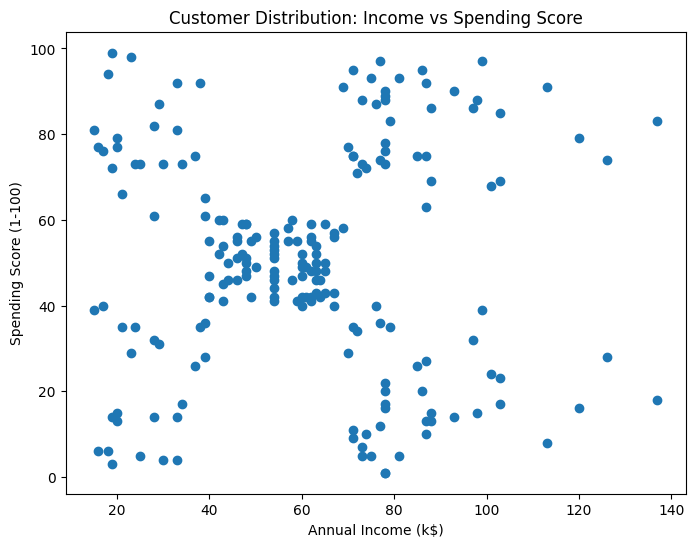

In [5]:
# Scatter plot: Annual Income vs Spending Score

plt.figure(figsize=(8, 6))

plt.scatter(
    df['Annual Income (k$)'],
    df['Spending Score (1-100)']
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Distribution: Income vs Spending Score')

plt.show()

**## 6. Feature Selection**

In [6]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

**## 7. Elbow Method**

In [7]:
from sklearn.cluster import KMeans

In [8]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42,
        n_init=10
    )

    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

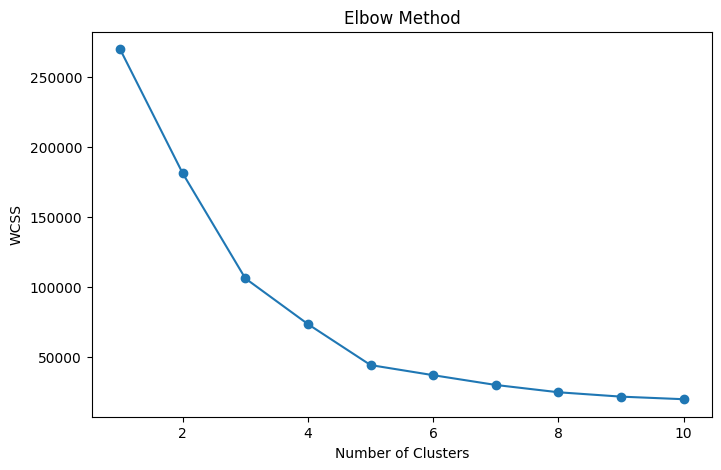

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(range(1, 11), wcss, marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()

**## 8. Train the K-Means Model**

In [10]:
kmeans = KMeans(
    n_clusters=5,
    init='k-means++',
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X)

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


**## 9. Visualize Customer Segments**

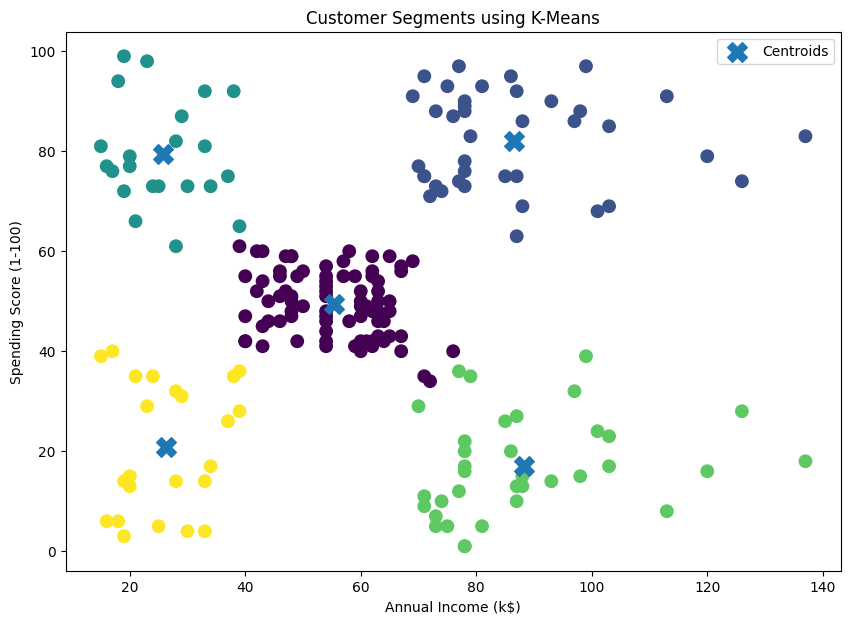

In [11]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X.iloc[:, 0],
    X.iloc[:, 1],
    c=df['Cluster'],
    s=80
)

# Cluster centers
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200,
    marker='X',
    label='Centroids'
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments using K-Means')
plt.legend()

plt.show()

**## 10. Cluster Analysis**

In [12]:
cluster_summary = df.groupby('Cluster').agg({
    'Annual Income (k$)': 'mean',
    'Spending Score (1-100)': 'mean',
    'Age': 'mean',
    'CustomerID': 'count'
}).round(2)

cluster_summary = cluster_summary.rename(
    columns={'CustomerID': 'Number of Customers'}
)

cluster_summary

,Annual Income (k$),Spending Score (1-100),Age,Number of Customers
Cluster,,,,
0,55.30,49.52,42.72,81
1,86.54,82.13,32.69,39
2,25.73,79.36,25.27,22
3,88.20,17.11,41.11,35
4,26.30,20.91,45.22,23


**## 11. Business Insights**

In [13]:
cluster_names = {
    0: 'Standard Customers',
    1: 'Premium Customers',
    2: 'High-Spending Customers',
    3: 'Potential Customers',
    4: 'Low-Value Customers'
}

df['Customer Segment'] = df['Cluster'].map(cluster_names)

df[['CustomerID', 'Annual Income (k$)',
    'Spending Score (1-100)', 'Customer Segment']].head(10)

,CustomerID,Annual Income (k$),Spending Score (1-100),Customer Segment
0,1,15,39,Low-Value Customers
1,2,15,81,High-Spending Customers
2,3,16,6,Low-Value Customers
3,4,16,77,High-Spending Customers
4,5,17,40,Low-Value Customers
5,6,17,76,High-Spending Customers
6,7,18,6,Low-Value Customers
7,8,18,94,High-Spending Customers
8,9,19,3,Low-Value Customers
9,10,19,72,High-Spending Customers


### Conclusion

The K-Means clustering algorithm successfully divided customers into five distinct segments based on their Annual Income and Spending Score. These segments can help businesses understand customer behavior and create targeted marketing strategies.